# Handwritten Digit Recognition(without PCA)Logistic Regression and SVM

## Problem Statement
Build a machine learning model to accurately recognize handwritten digits (0–9) from the MNIST dataset. Since each image contains 784 pixel features, apply Principal Component Analysis (PCA) to reduce dimensionality while preserving important information, and use Logistic Regression to classify the handwritten digits efficiently.


## Business Objective
- Automate handwritten digit recognition.
- Reduce feature dimensions using PCA.
- Improve training speed and computational efficiency.
- Maintain high classification accuracy with fewer features.

## Project Workflow

* Project Initialization
* Import Required Libraries      
* Load MNIST Dataset     
* Understand Dataset
* Exploratory Data Analysis (EDA)    
* Visualize Sample Images    
* Data Preprocessing       
* Feature Scaling  
* Introduction to PCA      
* Apply PCA  
* Explained Variance Ratio      
* Scree Plot     
* Cumulative Explained Variance      
* Select Optimal Principal Components      
* Transform Dataset      
* Train-Test Split      
* Train Logistic Regression Model       
* Model Prediction       
* Performance Evaluation        
* Compare Before PCA vs After PCA        
* Conclusion



## step1: Import Required Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('mnist_train.csv')
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df.shape

(60000, 785)

In [9]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [11]:
df.isna().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,0
28x25,0
28x26,0
28x27,0


In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


In [15]:
df['label'].value_counts()

,count
label,
1,6742
7,6265
3,6131
2,5958
9,5949
0,5923
6,5918
8,5851
4,5842


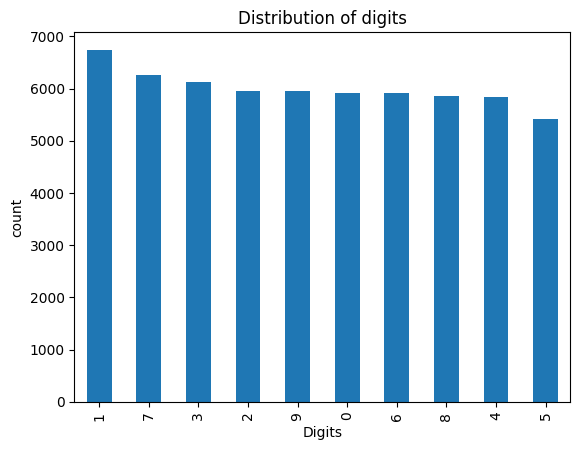

In [16]:
df['label'].value_counts().plot(kind='bar')
plt.title("Distribution of digits")
plt.xlabel("Digits")
plt.ylabel("count")
plt.show()


## Dataset Understanding

The MNIST dataset contains handwritten digit images from 0 to 9. Each row represents one handwritten digit image, and each column represents a pixel value of that image.

### Dataset Shape

```python
(60000, 785)
```

- **60000 Rows** → Total handwritten digit images.
- **785 Columns** → 1 Target Column + 784 Pixel Columns.

### Column Information

#### Target Column

```text
label
```

The `label` column contains the actual digit.

Example:

| label |
|---------|
| 0 |
| 1 |
| 5 |
| 9 |

This is the output variable (Target Variable).

---

#### Feature Columns

```text
1x1, 1x2, 1x3, ..., 28x28
```

These columns represent pixel values of a 28 × 28 grayscale image.

Since:

```text
28 × 28 = 784
```

there are 784 feature columns.

Each pixel stores an intensity value ranging from:

```text
0 → Black
255 → White
```

A handwritten digit image is converted into numerical pixel values so that machine learning algorithms can process it.

---

### Why Does the Dataset Have 784 Features?

Each handwritten digit image contains:

```text
28 Rows × 28 Columns
```

When the image is flattened into a single row:

```text
28 × 28 = 784 Features
```

Thus, every image becomes a row containing 784 pixel values.

---

### Problem with High Dimensional Data

The dataset contains:

```text
784 Features
```

Training a machine learning model directly on all 784 features can:

- Increase computational cost
- Increase training time
- Introduce redundant information
- Increase model complexity
- Make visualization difficult

This problem is known as the **Curse of Dimensionality**.

---

## Why Are We Applying PCA?

Principal Component Analysis (PCA) is a dimensionality reduction technique.

PCA transforms the original 784 features into a smaller set of new features called Principal Components while preserving most of the important information.

Example:

```text
Original Features = 784

After PCA = 331 Components
```

Instead of training on 784 features, the model may train on only 50 principal components while retaining most of the image information.

---

## Benefits of PCA

- Reduces dimensionality
- Removes redundant information
- Reduces noise
- Faster model training
- Lower memory usage
- Easier visualization
- Improves computational efficiency

---

## Project Goal

In this project, we will:

1. Understand the MNIST dataset.
2. Visualize handwritten digit images.
3. Scale the pixel values.
4. Apply Principal Component Analysis (PCA).
5. Analyze Explained Variance Ratio.
6. Select the optimal number of principal components.
7. Transform the dataset using PCA.
8. Train a Logistic Regression model.
9. Evaluate model performance.
10. Compare results before and after PCA.

The main objective is to reduce 784 image features into a smaller number of meaningful principal components while maintaining high digit classification accuracy.

##Step 4: Exploratory Data Analysis (EDA).

## Missing Value Analysis

The dataset contains **39 missing values**. Before applying PCA and Logistic Regression, missing values must be handled because these algorithms require complete numerical data.

The next step is to identify which columns contain missing values and decide the appropriate treatment method (such as removing rows or imputing values).

In [17]:
#checking and removing missing value
df.isna().sum()[df.isna().sum()>0]

,0


In [18]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [19]:
df.isna().sum().sum()

np.int64(0)

##Step 5: Visualize Sample Images


The MNIST dataset contains grayscale handwritten digit images represented as pixel values. Before building a machine learning model, it is important to visualize a few sample images to understand how the digits are stored and verify that the dataset has been loaded correctly.

Each image consists of **28 × 28 pixels (784 features)**. Every pixel value ranges from **0 (black)** to **255 (white)**. During visualization, these 784 features are reshaped back into a 28 × 28 image.

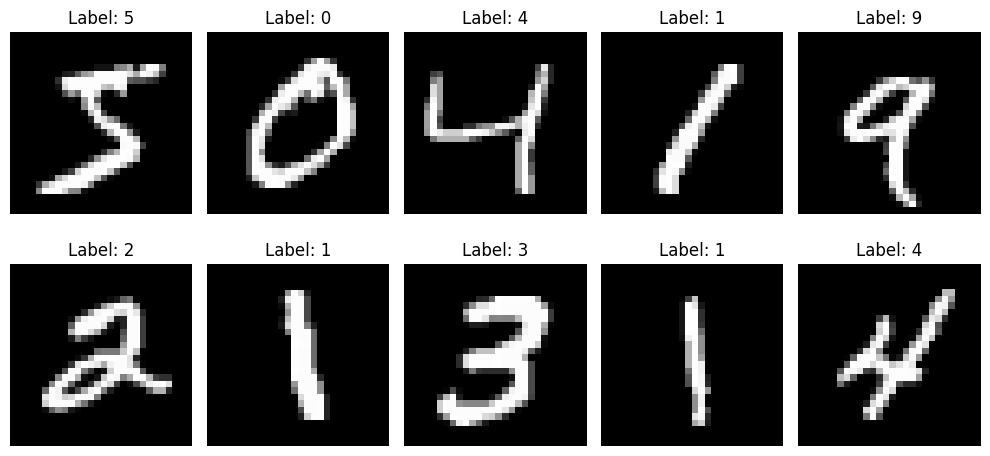

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(df.iloc[i,1:].values.reshape(28,28), cmap='gray')
    plt.title(f"Label: {df.iloc[i,0]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#Step 6: Data Preprocessing
## 6.1 Separate Features and Target

In [21]:
X = df.drop('label', axis = 1)
y = df['label']
X.head()

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
y.head()

,label
0,5
1,0
2,4
3,1
4,9


In [23]:
y.value_counts()

,count
label,
1,6742
7,6265
3,6131
2,5958
9,5949
0,5923
6,5918
8,5851
4,5842


# Step 7: Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_scaled = ss.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.033171,-0.022463,-0.016069,-0.011432,-0.009007,-0.00577,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.033171,-0.022463,-0.016069,-0.011432,-0.009007,-0.00577,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.033171,-0.022463,-0.016069,-0.011432,-0.009007,-0.00577,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.033171,-0.022463,-0.016069,-0.011432,-0.009007,-0.00577,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.033171,-0.022463,-0.016069,-0.011432,-0.009007,-0.00577,0.0,0.0,0.0,0.0


# PRINCIPLE COMPONENT ANALYSIS


In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(60000, 331)


In [26]:
import matplotlib.pyplot as plt

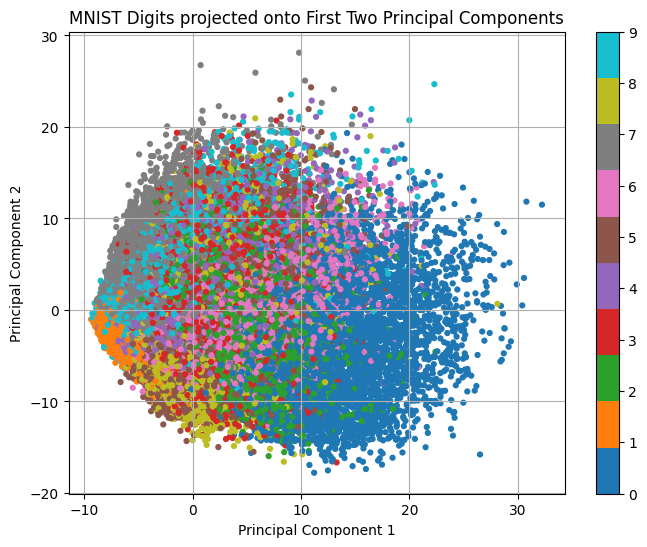

In [27]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='tab10',
    s=12
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST Digits projected onto First Two Principal Components")
plt.colorbar(scatter)
plt.grid(True)
plt.show()

# Step 8: Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(48000, 784)
(12000, 784)
(48000,)
(12000,)


In [29]:
print("df:", df.shape)
print("X:", X.shape)
print("X_scaled:", X_scaled.shape)

print("y:", y.shape)

df: (60000, 785)
X: (60000, 784)
X_scaled: (60000, 784)
y: (60000,)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:
model1 = LogisticRegression()
model1.fit(X_train, y_train)


LogisticRegression()

In [32]:
y_train_pred = model1.predict(X_train)


In [33]:
print('Training Accuracy', accuracy_score(y_train, y_train_pred))


Training Accuracy 0.9447708333333333


In [34]:
y_test_pred = model1.predict(X_test)

In [35]:
print('Testing Accuracy', accuracy_score(y_test, y_test_pred))

Testing Accuracy 0.914


In [36]:
print(confusion_matrix(y_test, y_test_pred))

[[1145    0    5    1    2   14    8    3    6    1]
 [   0 1304    9    6    1    5    1    2   17    3]
 [  10   16 1049   22    9    6   17   15   41    7]
 [   4    9   41 1075    2   38    1    9   35   12]
 [   5    3    9    1 1072    2    8   10    9   49]
 [  12    4   12   25   12  961   14    1   32   11]
 [   8    2    4    2   14   25 1122    1    6    0]
 [   5    7   18    5   10    3    1 1156    7   41]
 [  12   28   14   36    5   33   16    2 1007   17]
 [   1   10    4   11   27    7    2   43    8 1077]]


In [37]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1185
           1       0.94      0.97      0.95      1348
           2       0.90      0.88      0.89      1192
           3       0.91      0.88      0.89      1226
           4       0.93      0.92      0.92      1168
           5       0.88      0.89      0.88      1084
           6       0.94      0.95      0.95      1184
           7       0.93      0.92      0.93      1253
           8       0.86      0.86      0.86      1170
           9       0.88      0.91      0.89      1190

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000

